## Dataset overview

The CSV contains **34,660 customer-review records** and **21 columns**. It combines product details (such as name, brand, and category) with review information (including text, title, rating, recommendation, helpfulness, and dates). The exploration below checks the dataset's structure and data quality, then summarizes review ratings, recommendations, and text lengths.

In [6]:
import pandas as pd

df = pd.read_csv("../data/1429_1.csv")  # If the notebook is in the models folder
display(df.head())

print(f"Dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nData types and non-null counts:")
df.info()

print("\nMissing values by column:")
missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0].rename("missing_values").to_frame())

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

print("\nNumeric columns summary:")
display(df.select_dtypes(include="number").describe().T)

print("\nReview rating counts (including missing ratings):")
display(df["reviews.rating"].value_counts(dropna=False).sort_index().rename("count").to_frame())

print("\nRecommendation counts (including missing values):")
display(df["reviews.doRecommend"].value_counts(dropna=False).rename("count").to_frame())

print("\nReview text length summary (characters):")
display(df["reviews.text"].dropna().str.len().describe().to_frame())

/tmp/ipykernel_3245/648916783.py:3: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/1429_1.csv")  # If the notebook is in the models folder


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


Dataset dimensions: 34,660 rows x 21 columns

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float

,missing_values
reviews.userCity,34660
reviews.userProvince,34660
reviews.id,34659
reviews.didPurchase,34659
reviews.dateAdded,10621
name,6760
reviews.doRecommend,594
reviews.numHelpful,529
reviews.date,39
reviews.rating,33



Duplicate rows: 0

Numeric columns summary:


...

,count
reviews.rating,
1.0,410
2.0,402
3.0,1499
4.0,8541
5.0,23775
NaN,33



Recommendation counts (including missing values):


,count
reviews.doRecommend,
True,32682
False,1384
NaN,594



Review text length summary (characters):


,reviews.text
count,34659.000000
mean,159.047434
std,185.837884
min,3.000000
25%,70.000000
50%,106.000000
75%,183.000000
max,10670.000000


In [7]:
# Ratings are used only to create the label; product/user metadata and other fields are excluded.
rating_to_sentiment = {
    1: "negative",
    2: "negative",
    3: "neutral",
    4: "positive",
    5: "positive",
}

ratings = pd.to_numeric(df["reviews.rating"], errors="coerce")
review_text = df["reviews.text"].fillna("").astype(str).str.strip()
review_title = df["reviews.title"].fillna("").astype(str).str.strip()
sentiment = ratings.map(rating_to_sentiment)

combined_text = review_text.where(
    review_title.eq(""), review_title + ". " + review_text
)
valid_reviews = sentiment.notna() & review_text.ne("")

model_df = pd.DataFrame(
    {
        "text": combined_text[valid_reviews],
        "sentiment": sentiment[valid_reviews],
    }
).reset_index(drop=True)

print(f"Rows retained for modeling: {len(model_df):,} / {len(df):,}")
print("Sentiment class counts:")
display(model_df["sentiment"].value_counts().rename("count").to_frame())
display(model_df.head())

Rows retained for modeling: 34,626 / 34,660
Sentiment class counts:


,count
sentiment,
positive,32315
neutral,1499
negative,812


,text,sentiment
0,Kindle. This product so far has not disappoint...,positive
1,very fast. great for beginner or experienced p...,positive
2,Beginner tablet for our 9 year old son.. Inexp...,positive
3,Good!!!. I've had my Fire HD 8 two weeks now a...,positive
4,Fantastic Tablet for kids. I bought this for m...,positive


## Train and evaluate a baseline model

This baseline uses TF-IDF features from review text and a class-weighted logistic regression classifier. The stratified test split keeps all three sentiment classes represented; ratings and metadata are not model inputs. The evaluation reports per-class precision, recall, and F1, along with accuracy and a confusion matrix.

Test accuracy: 90.07%

Per-class and overall metrics:


,precision,recall,f1-score,support
negative,0.471616,0.666667,0.552430,162.000000
neutral,0.250853,0.490000,0.331828,300.000000
positive,0.979054,0.925588,0.951571,6464.000000
accuracy,0.900664,0.900664,0.900664,0.900664
macro avg,0.567174,0.694085,0.611943,6926.000000
weighted avg,0.935643,0.900664,0.915390,6926.000000



Confusion matrix (counts):


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,108,32,22
Actual neutral,47,147,106
Actual positive,74,407,5983


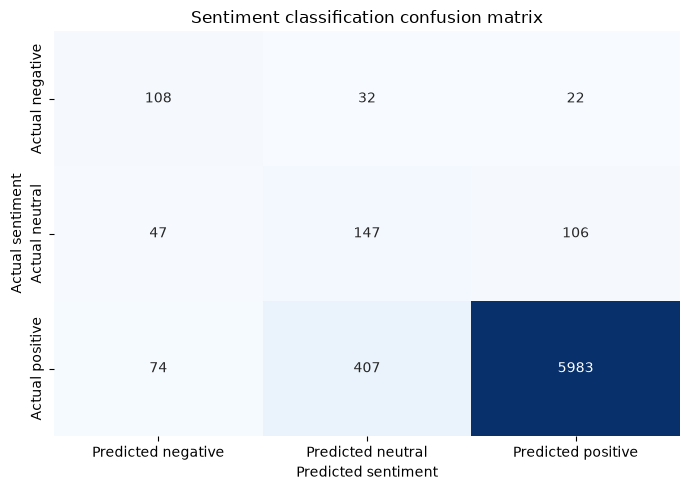

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    model_df["text"],
    model_df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=model_df["sentiment"],
)

sentiment_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=100_000)),
        ("classifier", LogisticRegression(class_weight="balanced", max_iter=1_000)),
    ]
)
sentiment_model.fit(X_train, y_train)
y_pred = sentiment_model.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nPer-class and overall metrics:")
display(pd.DataFrame(classification_report(
    y_test,
    y_pred,
    labels=["negative", "neutral", "positive"],
    output_dict=True,
    zero_division=0,
)).T)

class_labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, y_pred, labels=class_labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels],
)
print("\nConfusion matrix (counts):")
display(cm_df)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Sentiment classification confusion matrix")
ax.set_xlabel("Predicted sentiment")
ax.set_ylabel("Actual sentiment")
plt.tight_layout()
plt.show()

## Fine-tune a pretrained transformer

This notebook cell uses only the original `1429_1.csv` dataset. The reproducible training script `train_transformer.py` uses the same dataset with stratified train, validation, and test splits. A CUDA GPU is recommended.

Training on: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\zinam\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zinam\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mean training loss: 0.8356
DistilBERT test accuracy: 93.96%

DistilBERT per-class and overall metrics:


,precision,recall,f1-score,support
negative,0.653846,0.734568,0.691860,162.000000
neutral,0.371585,0.453333,0.408408,300.000000
positive,0.980401,0.967358,0.973836,6464.000000
accuracy,0.939648,0.939648,0.939648,0.939648
macro avg,0.668611,0.718420,0.691368,6926.000000
weighted avg,0.946392,0.939648,0.942749,6926.000000



DistilBERT confusion matrix (counts):


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,119,35,8
Actual neutral,47,136,117
Actual positive,16,195,6253


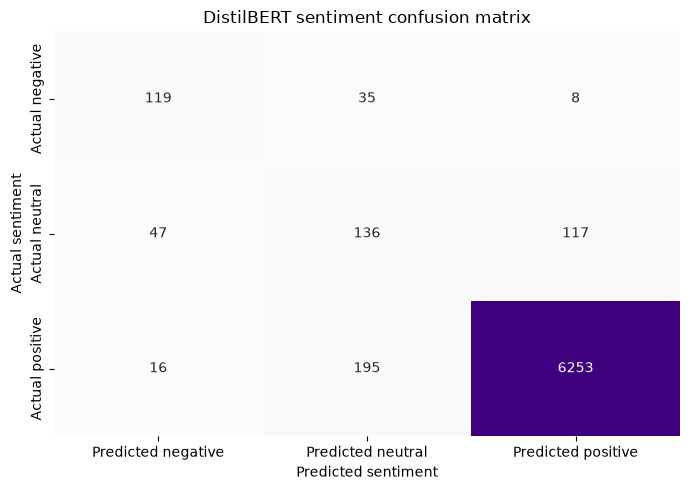

In [9]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "distilbert-base-uncased"
label_names = ["negative", "neutral", "positive"]
label_to_id = {label: index for index, label in enumerate(label_names)}
id_to_label = {index: label for label, index in label_to_id.items()}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
if device.type == "cpu":
    print("Warning: transformer fine-tuning on CPU can be very slow.")

tokenizer = AutoTokenizer.from_pretrained(model_name)
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label=id_to_label,
    label2id=label_to_id,
).to(device)

max_length = 192
batch_size = 16

def make_dataset(texts, labels):
    encodings = tokenizer(
        texts.tolist(),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    )
    label_ids = torch.tensor(labels.map(label_to_id).to_numpy(), dtype=torch.long)
    return TensorDataset(encodings["input_ids"], encodings["attention_mask"], label_ids)

train_dataset = make_dataset(X_train, y_train)
test_dataset = make_dataset(X_test, y_test)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type == "cuda",
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=device.type == "cuda",
)

train_label_ids = y_train.map(label_to_id).to_numpy()
class_counts = np.bincount(train_label_ids, minlength=len(label_names))
class_weights = len(train_label_ids) / (len(label_names) * class_counts)
loss_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion = torch.nn.CrossEntropyLoss(weight=loss_weights)
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=2e-5)

transformer_model.train()
total_loss = 0.0
for batch in train_loader:
    input_ids, attention_mask, labels = (tensor.to(device) for tensor in batch)
    optimizer.zero_grad(set_to_none=True)
    outputs = transformer_model(input_ids=input_ids, attention_mask=attention_mask)
    loss = criterion(outputs.logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)
    optimizer.step()
    total_loss += loss.item()

print(f"Mean training loss: {total_loss / len(train_loader):.4f}")

transformer_model.eval()
transformer_predictions = []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, _ = (tensor.to(device) for tensor in batch)
        logits = transformer_model(input_ids=input_ids, attention_mask=attention_mask).logits
        transformer_predictions.extend(logits.argmax(dim=1).cpu().tolist())

y_transformer_pred = [id_to_label[index] for index in transformer_predictions]
print(f"DistilBERT test accuracy: {accuracy_score(y_test, y_transformer_pred):.2%}")
print("\nDistilBERT per-class and overall metrics:")
display(pd.DataFrame(classification_report(
    y_test,
    y_transformer_pred,
    labels=label_names,
    output_dict=True,
    zero_division=0,
)).T)

transformer_cm = confusion_matrix(y_test, y_transformer_pred, labels=label_names)
transformer_cm_df = pd.DataFrame(
    transformer_cm,
    index=[f"Actual {label}" for label in label_names],
    columns=[f"Predicted {label}" for label in label_names],
)
print("\nDistilBERT confusion matrix (counts):")
display(transformer_cm_df)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(transformer_cm_df, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax)
ax.set_title("DistilBERT sentiment confusion matrix")
ax.set_xlabel("Predicted sentiment")
ax.set_ylabel("Actual sentiment")
plt.tight_layout()
plt.show()